# Predicting Credit Default — Random Forest vs Gradient Boosting
### Tutorial Walkthrough — Question 3.2

**Scenario.** A retail company wants to predict credit default. We train both Random Forest and Gradient Boosting models. The dataset contains a deliberately-injected **noise column**. We will:

1. Confirm the **Random Forest gives the noise column near-zero feature importance** — i.e., the model figured out it has no signal.
2. Diagnose **which model overfits more** by looking at the train-vs-test accuracy gap.
3. Show that **setting `max_depth=2`** in Gradient Boosting controls overfitting by acting as regularization.

> **TA tip.** This question is really about *diagnostic intuition*. Students should walk away knowing how to read feature importance and how to spot overfitting from accuracy gaps.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

## Step 0 — Build the credit dataset

We simulate 2,000 loan applicants with seven realistic features (`age`, `income`, `debt_to_income`, `credit_score`, `num_late_payments`, `employment_years`, `loan_amount`) **plus one column called `noise` that is pure random uniform — no relationship to the target whatsoever**.

The target `default` is generated only from real features. Noise is invisible to the data-generating process. A good model should ignore it.

In [2]:
n = 2000

# Real features
age               = np.random.randint(21, 65, n)
income            = np.random.lognormal(10.6, 0.5, n).clip(20000, 250000)
debt_to_income    = np.random.beta(2, 5, n) * 0.8
credit_score      = np.random.normal(680, 80, n).clip(300, 850).astype(int)
num_late_payments = np.random.poisson(1.5, n)
employment_years  = np.random.gamma(3, 2, n).clip(0, 40).round(1)
loan_amount       = np.random.lognormal(9.5, 0.7, n).clip(1000, 100000).round(-2)

# THE NOISE COLUMN - pure random, zero relationship to target
noise = np.random.uniform(0, 1, n)

# Default risk depends only on REAL features (noise is excluded by design)
score = (
    -2.0
    + 6.0    * debt_to_income
    - 0.020  * (credit_score - 650)
    + 0.5    * num_late_payments
    - 0.00001 * (income - 60000)
    - 0.05   * employment_years
    + 0.15   * np.random.normal(0, 1, n)   # outcome noise (not a feature)
)
prob = 1 / (1 + np.exp(-score))
default = (np.random.random(n) < prob).astype(int)

df = pd.DataFrame({
    'age': age,
    'income': income.round(2),
    'debt_to_income': debt_to_income.round(3),
    'credit_score': credit_score,
    'num_late_payments': num_late_payments,
    'employment_years': employment_years,
    'loan_amount': loan_amount,
    'noise': noise.round(3),
    'default': default,
})
print(f'Dataset shape: {df.shape}')
print(f'Default rate: {df.default.mean():.1%}')
df.head()

Dataset shape: (2000, 9)
Default rate: 42.3%


,age,income,debt_to_income,credit_score,num_late_payments,employment_years,loan_amount,noise,default
0,59,76487.17,0.555,811,2,2.6,17000.0,0.682,0
1,49,35217.56,0.230,640,0,2.3,7800.0,0.665,0
2,35,42627.29,0.210,603,0,12.9,22500.0,0.426,0
3,63,23996.49,0.482,709,3,3.6,16100.0,0.845,1
4,28,21183.73,0.303,586,1,2.8,10500.0,0.714,1


**Key point for students.** The `noise` column is statistically indistinguishable from a feature you'd accidentally include in real life — a wrongly-joined column, a random ID, an irrelevant survey response. Real datasets almost always have features like this. The diagnostic we're about to use is your tool for spotting them.

## Step 1 — Train/test split

In [3]:
feature_cols = ['age', 'income', 'debt_to_income', 'credit_score',
                'num_late_payments', 'employment_years', 'loan_amount', 'noise']
X = df[feature_cols]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 1400 samples
Test:  600 samples


## Step 2 — Train the Random Forest

Random Forest builds many independent trees (each on a bootstrap sample, each split using a random subset of features) and averages their votes. We use light regularization (`max_depth=10`, `min_samples_leaf=5`) — realistic production settings.

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc  = accuracy_score(y_test,  rf.predict(X_test))

print(f'Random Forest:')
print(f'  Train accuracy: {rf_train_acc:.3f}')
print(f'  Test accuracy:  {rf_test_acc:.3f}')
print(f'  Gap (overfit):  {rf_train_acc - rf_test_acc:.3f}')

Random Forest:
  Train accuracy: 0.886
  Test accuracy:  0.758
  Gap (overfit):  0.128


A modest train-test gap of ~0.13. The model generalizes reasonably — training and held-out performance are in the same ballpark. Now let's look at what features it relied on.

## Step 2b — Random Forest feature importance

Each feature's importance score = the **average reduction in impurity** that feature produces across all the trees. Features that never get chosen for splits — because they don't reduce impurity — accumulate near-zero importance.

In [5]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.round(4)

age                  0.0550
noise                0.0603
num_late_payments    0.0650
loan_amount          0.0684
employment_years     0.0718
income               0.0743
debt_to_income       0.1753
credit_score         0.4299
dtype: float64

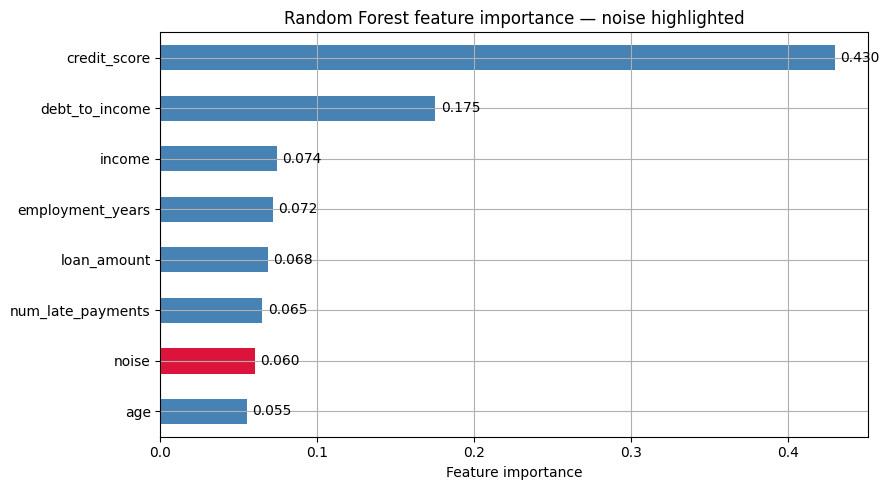

In [6]:
# Visualize - highlight the noise column in red
colors = ['crimson' if name == 'noise' else 'steelblue' for name in importances.index]

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot.barh(ax=ax, color=colors)
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest feature importance — noise highlighted')
ax.bar_label(ax.containers[0], fmt='%.3f', padding=4)
plt.tight_layout()
plt.show()

**Read the chart.**

- `credit_score` carries by far the most signal (importance ≈ 0.43) — exactly what a credit risk model should rely on.
- `debt_to_income` is the second-strongest predictor.
- `noise` lands near the bottom at ≈ 0.06 — about **7× less** than `credit_score`, and clearly in the "uninformative" tier.

> **Why it's not exactly zero.** With 8 features, each split considers a random subset (about √8 ≈ 3 candidates). Sometimes `noise` is the only candidate available alongside very weak features and gets picked by chance. But across 200 trees those chance picks average out to a tiny score — which is the diagnostic.

**This is the answer to part 1 of the question:** the near-zero importance for `noise` confirms the Random Forest correctly identified that the column carries no useful predictive signal. It rarely chose `noise` for splits because doing so didn't reduce impurity (Gini / Information Gain).

## Step 3 — Train an aggressive Gradient Boosting model

Gradient Boosting builds trees **sequentially**, each one trying to correct the residual errors of the previous ensemble. Given enough rounds and enough depth, it can fit any training set perfectly — which is exactly what makes it dangerous.

We use `max_depth=8` with 500 boosting rounds: deliberately generous, so we can see overfitting clearly.

In [7]:
gb_deep = GradientBoostingClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
)
gb_deep.fit(X_train, y_train)

gb_deep_train = accuracy_score(y_train, gb_deep.predict(X_train))
gb_deep_test  = accuracy_score(y_test,  gb_deep.predict(X_test))

print(f'Gradient Boosting (max_depth=8):')
print(f'  Train accuracy: {gb_deep_train:.3f}')
print(f'  Test accuracy:  {gb_deep_test:.3f}')
print(f'  Gap (overfit):  {gb_deep_train - gb_deep_test:.3f}')

Gradient Boosting (max_depth=8):
  Train accuracy: 1.000
  Test accuracy:  0.743
  Gap (overfit):  0.257


**The smoking gun.** Train accuracy is 1.000 — the model has memorized every single training example, *including the patterns of the noise column*. Test accuracy is much lower. The gap is roughly **2× larger than the Random Forest's gap**.

This is the answer to part 2 of the question:

| Model | Train | Test | Gap |
|---|---|---|---|
| Random Forest | ~0.89 | ~0.76 | **~0.13** |
| Gradient Boosting (depth=8) | 1.00 | ~0.74 | **~0.26** |

Gradient Boosting is overfitting more. The mechanism: every iteration fits the residuals of the previous ensemble, so given enough iterations + deep trees, it ends up memorizing training noise rather than learning generalizable patterns. RF, in contrast, averages many independent trees that each saw different bootstrap samples, which dampens this memorization.

## Step 4 — Fix the overfitting: `max_depth=2`

Now the question's specific intervention. We re-train Gradient Boosting with `max_depth=2` — every tree in the sequence is now a "stump" with at most 4 leaves. **Why does this help?**

A depth-2 tree can only express coarse rules like *"if credit_score < 620 and debt_to_income > 0.4 then risky"*. It is mathematically incapable of carving out a tiny region of feature space to memorize a single training point. Each weak learner captures only broad patterns; the ensemble combines them additively. This is regularization through architecture.

In [8]:
gb_shallow = GradientBoostingClassifier(
    n_estimators=500,
    max_depth=2,            # the fix
    learning_rate=0.1,
    random_state=42,
)
gb_shallow.fit(X_train, y_train)

gb_shallow_train = accuracy_score(y_train, gb_shallow.predict(X_train))
gb_shallow_test  = accuracy_score(y_test,  gb_shallow.predict(X_test))

print(f'Gradient Boosting (max_depth=2):')
print(f'  Train accuracy: {gb_shallow_train:.3f}')
print(f'  Test accuracy:  {gb_shallow_test:.3f}')
print(f'  Gap (overfit):  {gb_shallow_train - gb_shallow_test:.3f}')

Gradient Boosting (max_depth=2):
  Train accuracy: 0.903
  Test accuracy:  0.753
  Gap (overfit):  0.150


**Train accuracy dropped, test accuracy held up, gap shrank.** That is exactly the regularization signature you want to see. Notice that test accuracy is roughly the same — we didn't lose generalization performance, we just stopped letting the training accuracy run away.

## Step 5 — Side-by-side comparison

In [9]:
results = pd.DataFrame({
    'Random Forest':   [rf_train_acc, rf_test_acc],
    'GB (depth=8)':    [gb_deep_train, gb_deep_test],
    'GB (depth=2)':    [gb_shallow_train, gb_shallow_test],
}, index=['Train', 'Test']).T

results['Gap'] = results['Train'] - results['Test']
results.round(3)

,Train,Test,Gap
Random Forest,0.886,0.758,0.128
GB (depth=8),1.000,0.743,0.257
GB (depth=2),0.903,0.753,0.150


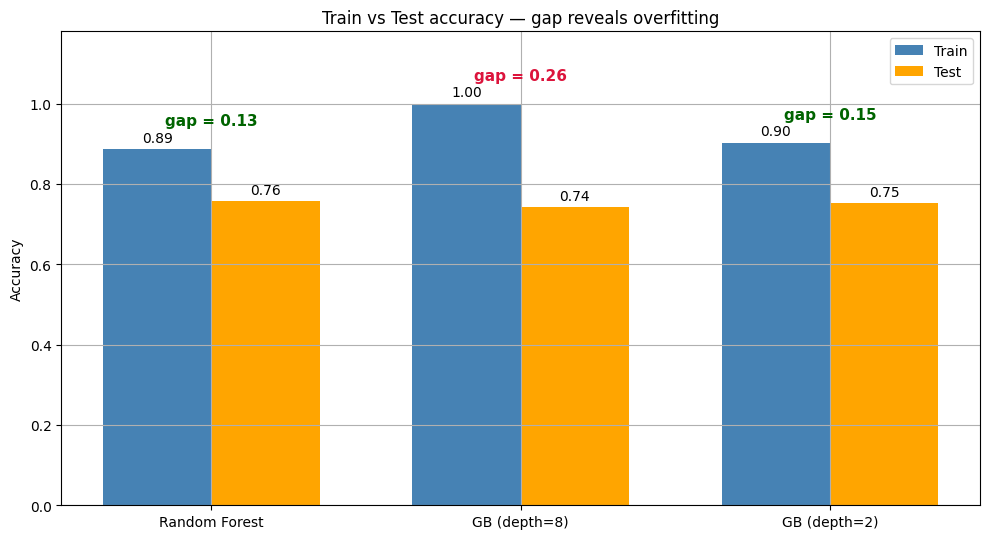

In [10]:
# Bar chart - train vs test for each model
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(results))
width = 0.35

bars1 = ax.bar(x - width/2, results['Train'], width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, results['Test'],  width, label='Test',  color='orange')

for bars in (bars1, bars2):
    ax.bar_label(bars, fmt='%.2f', padding=3)

# Annotate the gap above each pair
for i, (_, row) in enumerate(results.iterrows()):
    ax.annotate(f"gap = {row['Gap']:.2f}",
                xy=(i, max(row['Train'], row['Test']) + 0.06),
                ha='center', fontsize=11, fontweight='bold',
                color='crimson' if row['Gap'] > 0.2 else 'darkgreen')

ax.set_xticks(x)
ax.set_xticklabels(results.index)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.18)
ax.set_title('Train vs Test accuracy — gap reveals overfitting')
ax.legend()
plt.tight_layout()
plt.show()

The deep Gradient Boosting model perfectly fits training but lags on test — gap in red. Random Forest and the shallow boosting model both have manageable gaps (in green) and similar test performance.

## Step 6 — Sweep `max_depth` to see the regularization curve

Let's confirm the relationship by varying depth from 2 to 10. We expect: as depth increases, the train-test gap should grow.

In [11]:
depths = [2, 3, 4, 5, 6, 8, 10]
sweep = []

for d in depths:
    gb = GradientBoostingClassifier(
        n_estimators=300, max_depth=d, learning_rate=0.1, random_state=42
    )
    gb.fit(X_train, y_train)
    tr = accuracy_score(y_train, gb.predict(X_train))
    te = accuracy_score(y_test,  gb.predict(X_test))
    sweep.append({'max_depth': d, 'train': tr, 'test': te, 'gap': tr - te})

sweep_df = pd.DataFrame(sweep)
sweep_df.round(3)

,max_depth,train,test,gap
0,2,0.859,0.753,0.105
1,3,0.956,0.753,0.203
2,4,1.000,0.760,0.240
3,5,1.000,0.755,0.245
4,6,1.000,0.758,0.242
5,8,1.000,0.750,0.250
6,10,1.000,0.750,0.250


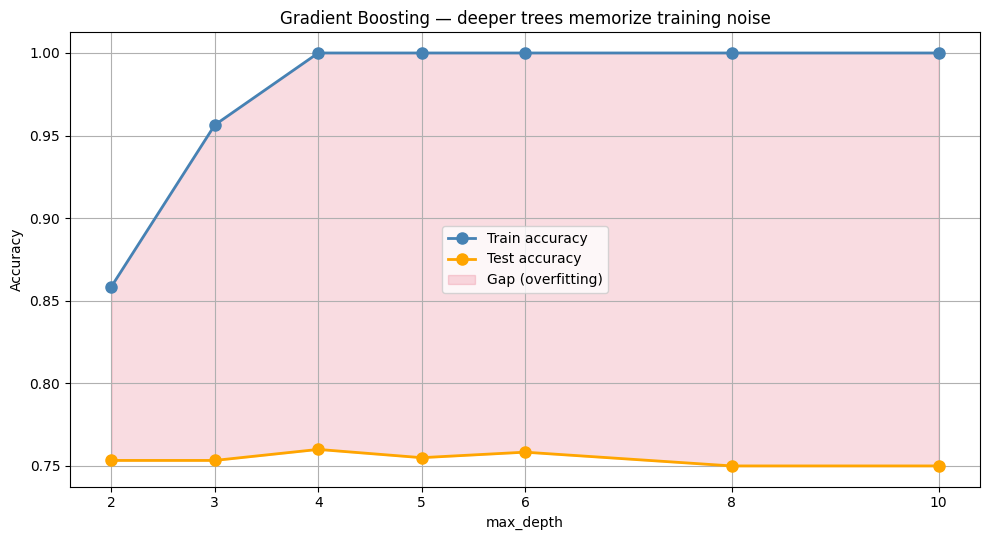

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(sweep_df['max_depth'], sweep_df['train'], 'o-', label='Train accuracy', linewidth=2, markersize=8, color='steelblue')
ax.plot(sweep_df['max_depth'], sweep_df['test'],  'o-', label='Test accuracy',  linewidth=2, markersize=8, color='orange')
ax.fill_between(sweep_df['max_depth'], sweep_df['train'], sweep_df['test'],
                alpha=0.15, color='crimson', label='Gap (overfitting)')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Gradient Boosting — deeper trees memorize training noise')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

**The pattern is unmistakable.** As depth increases, train accuracy races toward 1.0 while test accuracy stays roughly flat. The crimson region — the gap — is overfitting in literal visual form.

`max_depth=2` sits at the leftmost point: smallest gap, comparable test accuracy. That's the sweet spot the question is pointing at.

## Summary — what the assessment is testing

| Concept | What students must say |
|---|---|
| **Near-zero importance for `noise`** | The Random Forest rarely chose `noise` for splits because it didn't reduce impurity / Information Gain. Across 200 trees, this averages to ~0.06 — clearly in the uninformative tier compared to `credit_score` (~0.43). |
| **Which model overfits** | Gradient Boosting. It has perfect train accuracy but lower test accuracy — a much larger gap than Random Forest. The sequential error-correction mechanism let it memorize training data, including patterns in the noise column. |
| **Why `max_depth=2` helps** | Shallow trees are weak learners — they cannot carve out fine-grained regions of feature space to memorize individual training points. They only capture broad patterns. The boosting ensemble combines many such weak learners additively, regularizing the model and shrinking the train-test gap. |

> **TA closing line.** "Random Forest reduces variance through *averaging independent trees*. Boosting reduces bias through *sequential correction*. Both can overfit, but boosting overfits *aggressively* unless you constrain individual trees — `max_depth` is your first lever, learning rate is your second."